In [1]:
import pandas as pd 
import sys
sys.path.append('../../code')
import plot_of_experiment_data 
import matplotlib.pyplot as plt
import matplotlib
import warnings
import numpy as np 
warnings.filterwarnings("ignore", message="findfont: Font family 'Arial' not found.")
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'

In [2]:
def std_err(arr):
    err = np.nanstd(arr,axis=0)/np.sqrt(np.sum(~np.isnan(arr),axis=0))
    return err

def pval_to_asterisks(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


In [3]:
fpath = '/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure3/fig3f/data/kir2.1_LH_lines.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
# sheets = ['']
data_df_figH = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_figH[s] = df
    
mean_df_figH = pd.DataFrame(index=sheets,columns=['sugar','sugar+geosmin'])
std_df_figH = pd.DataFrame(index=sheets,columns=['sugar','sugar+geosmin'])
for i,df in data_df_figH.items():
    mean_df_figH.loc[i] = df.mean()
    std_df_figH.loc[i] = std_err(df)

mean_df_figH.loc['w118'] = [0.645833333333333,0.3125]
std_df_figH.loc['w118'] = [0,0]

In [10]:
data_df_figH['LH1990']['sugar+geosmin']-data_df_figH['LH1990']['sugar']

0   -0.083333
1   -0.041667
2    0.000000
3   -0.041667
4   -0.041667
dtype: float64

In [7]:
{x:y['sugar+geosmin']-y['sugar'] for x,y in data_df_figH.items()}

{'w118': 0   -0.333333
 1   -0.416667
 2   -0.333333
 3   -0.375000
 4   -0.208333
 5   -0.333333
 dtype: float64,
 'LH1983': 0   -0.041667
 1    0.041667
 2   -0.041667
 3    0.041667
 4    0.000000
 dtype: float64,
 'LH1989': 0   -0.041667
 1    0.083333
 2   -0.041667
 3    0.000000
 4    0.000000
 dtype: float64,
 'LH1990': 0   -0.083333
 1   -0.041667
 2    0.000000
 3   -0.041667
 4   -0.041667
 dtype: float64}

/home/se/anaconda3/envs/flywire/lib/python3.9/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' n

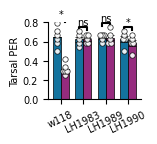

In [4]:
fig,ax = plt.subplots(1,1,figsize=(1.2,1))

ax,stat_all = plot_of_experiment_data.draw_paired_bar_figure(
    data=data_df_figH,
    mean_df=mean_df_figH,
    err_df=std_df_figH,
    bar_width = 0.25,
    bar_spacing=.7,
    stat_fontsize = 7,
    fontsize=7,
    ax=ax,
    conds=['w118','LH1983','LH1989','LH1990'],
    groups=['sugar', 'sugar+geosmin'],
    get_values=lambda data, cond, group: data[cond][group],
    stat_pairs=[
        (('w118', 'sugar'), ('w118', 'sugar+geosmin')),
        (('LH1983', 'sugar'), ('LH1983', 'sugar+geosmin')),
        (('LH1989', 'sugar'), ('LH1989', 'sugar+geosmin')),
        (('LH1990', 'sugar'), ('LH1990', 'sugar+geosmin'))
    ],
    colors=('#13739E', '#952B7E'),
    ylabel='Tarsal PER',
    xtick_func=lambda c: c.split('>')[0],
    ylim=(0, 0.8),
    yticks=np.round(np.arange(0, .81, .2), 2)
)
ax.tick_params('x',rotation=25)


In [19]:
import matplotlib.pyplot as plt
import distinctipy
import numpy as np 
import pandas as pd 
import os 
import pickle
from scipy.stats import mannwhitneyu,ranksums,wilcoxon,shapiro
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'



data=data_df_figH
conds=['w118','LH1983','LH1989','LH1990']
get_values=lambda data, cond, group: data[cond][group]
stat_pairs=[
    (('w118', 'sugar'), ('w118', 'sugar+geosmin')),
    (('LH1983', 'sugar'), ('LH1983', 'sugar+geosmin')),
    (('LH1989', 'sugar'), ('LH1989', 'sugar+geosmin')),
    (('LH1990', 'sugar'), ('LH1990', 'sugar+geosmin'))
]
stat_all = []
for pair_idx, ((cond1, group1), (cond2, group2)) in enumerate(stat_pairs):
    v1 = np.array(get_values(data, cond1, group1), dtype=float)
    v2 = np.array(get_values(data, cond2, group2), dtype=float)
    print(v1,v2)
    valid = ~np.isnan(v1) & ~np.isnan(v2)
    v1 = v1[valid]
    v2 = v2[valid]

    stat, pval = wilcoxon(v1, v2, alternative='greater',method='auto')
    stat_all.append((stat,pval))




[0.66666667 0.70833333 0.625      0.79166667 0.5        0.58333333] [0.33333333 0.29166667 0.29166667 0.41666667 0.29166667 0.25      ]
[0.70833333 0.58333333 0.625      0.54166667 0.66666667] [0.66666667 0.625      0.58333333 0.58333333 0.66666667]
[0.625      0.66666667 0.66666667 0.66666667 0.58333333] [0.58333333 0.75       0.625      0.66666667 0.58333333]
[0.66666667 0.70833333 0.625      0.625      0.5       ] [0.58333333 0.66666667 0.625      0.58333333 0.45833333]


In [26]:
v1 = [0.66666667,0.70833333, 0.625,      0.625,      0.5       ]
v2 = [0.58333333 ,0.66666667, 0.625,      0.58333333,0.45833333]
wilcoxon(v1, v2, alternative='greater',method='auto')

WilcoxonResult(statistic=10.0, pvalue=0.032799846073535935)

In [23]:
np.array(v1)-np.array(v2)

array([0.08333334, 0.04166666, 0.        , 0.04166667, 0.04166667])